In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Semester 6/BI/UTS/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Semester 6/BI/UTS/test.csv")

In [ ]:
print("=== TRAIN DATA (kolom 0-7) ===")
print((train.iloc[:,0:7].head()).to_string())

print("\n=== TRAIN DATA (kolom 8-15) ===")
print((train.iloc[:,8:15].head()).to_string())

print("\n=== TEST DATA (kolom 0-7) ===")
print((test.iloc[:,0:7].head()).to_string())

print("\n=== TEST DATA (kolom 8-15) ===")
print((test.iloc[:,8:15].head()).to_string())

=== TRAIN DATA (kolom 0-7) ===
   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel     Class
0           0   70172    Male     Loyal Customer   13  Personal Travel  Eco Plus
1           1    5047    Male  disloyal Customer   25  Business travel  Business
2           2  110028  Female     Loyal Customer   26  Business travel  Business
3           3   24026  Female     Loyal Customer   25  Business travel  Business
4           4  119299    Male     Loyal Customer   61  Business travel  Business

=== TRAIN DATA (kolom 8-15) ===
   Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort
0                      3                                  4                       3              1               5                3             5
1                      3                                  2                       3              3               1                3             1
2           

In [ ]:
# Gabungkan train + test biar analisis lebih lengkap
df = pd.concat([train, test], ignore_index=True)

# Cek missing value
print(df.isnull().sum())

# Isi missing dengan mean (untuk numerik)
df.fillna(df.mean(numeric_only=True), inplace=True)

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction    

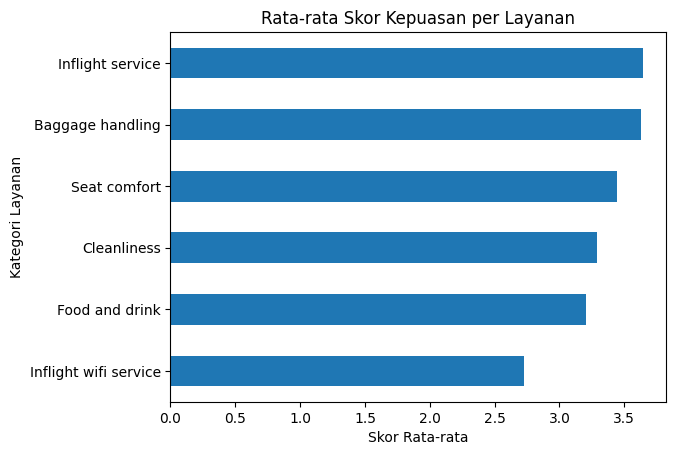

In [ ]:
# Pilih kolom layanan (biasanya ada di dataset airline)
service_cols = [
    'Inflight wifi service',
    'Seat comfort',
    'Food and drink',
    'Baggage handling',
    'Inflight service',
    'Cleanliness'
]

# Hitung rata-rata
mean_scores = df[service_cols].mean()

# Plot
plt.figure()
mean_scores.sort_values().plot(kind='barh')
plt.title("Rata-rata Skor Kepuasan per Layanan")
plt.xlabel("Skor Rata-rata")
plt.ylabel("Kategori Layanan")
plt.show()

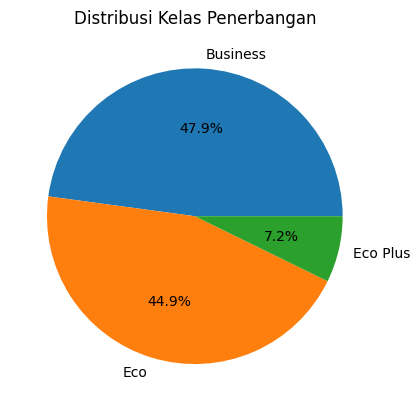

In [ ]:
flight_class = df['Class'].value_counts()

plt.figure()
plt.pie(flight_class, labels=flight_class.index, autopct='%1.1f%%')
plt.title("Distribusi Kelas Penerbangan")
plt.show()

In [ ]:
print(df.groupby('Class')['satisfaction'].value_counts(normalize=True))

Class     satisfaction           
Business  satisfied                  0.694434
          neutral or dissatisfied    0.305566
Eco       neutral or dissatisfied    0.812327
          satisfied                  0.187673
Eco Plus  neutral or dissatisfied    0.753586
          satisfied                  0.246414
Name: proportion, dtype: float64


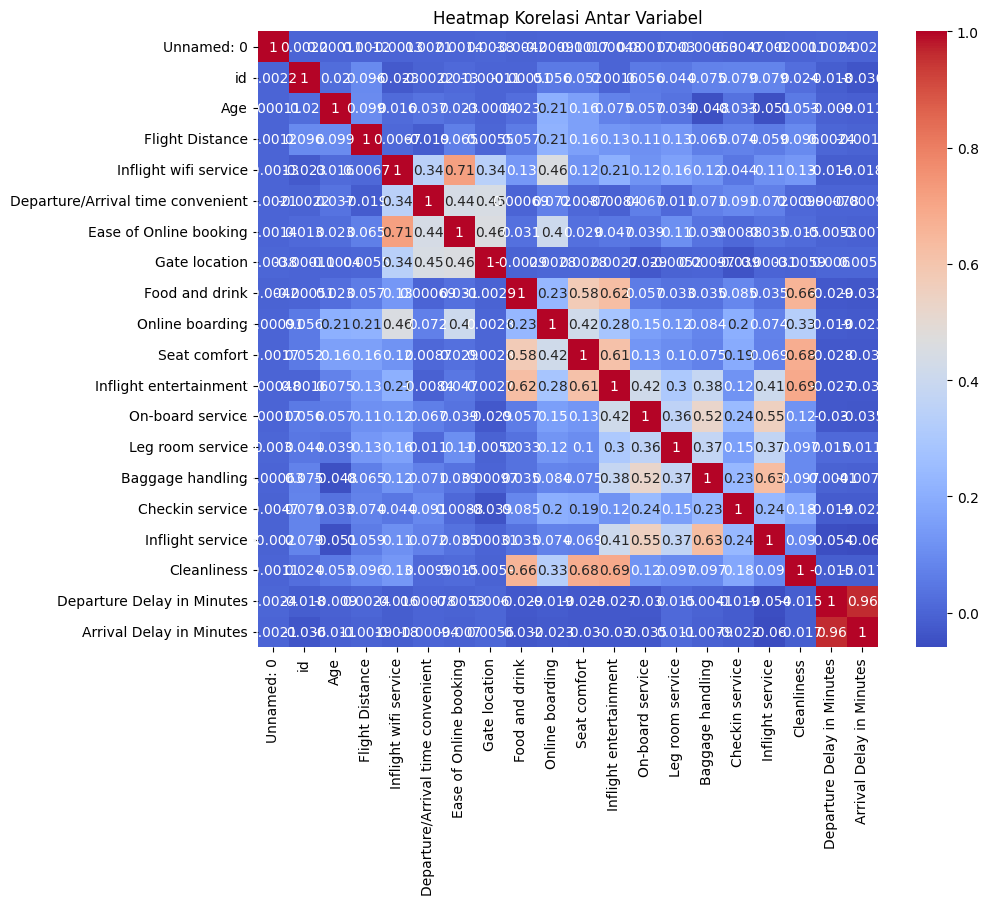

In [ ]:
# Ambil hanya numerik
numeric_df = df.select_dtypes(include=np.number)

# Hitung korelasi
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

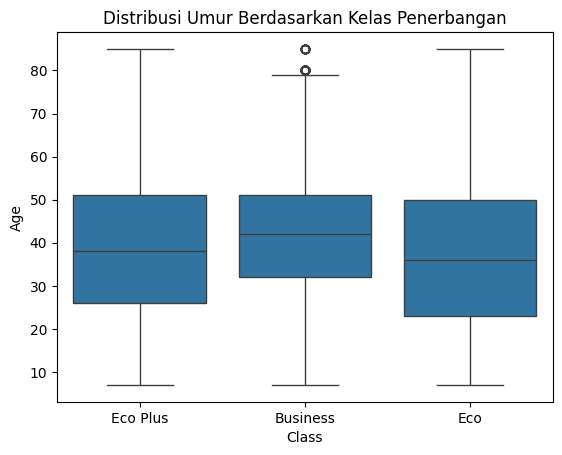

In [ ]:
sns.boxplot(x='Class', y='Age', data=df)
plt.title("Distribusi Umur Berdasarkan Kelas Penerbangan")
plt.show()